## Preprocessing Pipeline (Work Folder, Exploratory Analysis, Motion Correction)


### 1.   Creation of Work Folder + Exploratory Analysis (Mandatory)

In [17]:
# 1: CREATION OF THE WORK FOLDER

import os
import json
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from reader_tiff import scan_channels, load_worker
from IPython.display import display
from project_setup import generate_setup_panel

paths = {}

panel = generate_setup_panel(paths)
display(panel)

In [18]:
# 2: METADATA EXTRACTION

from IPython.display import display
from reader_xml import extract_metadata_panel

# Scan of Metadata Script
ui_fallback = extract_metadata_panel(paths)

# If fps/XML is not present 
if ui_fallback:
    display(ui_fallback)

===== METADATA EXTRACTED =====
frame_period: 0.9557
fps: 1.046
pixels_y: 512
um_per_pixel_x: 1.157
um_per_pixel_y: 1.157
pixels_x: 512
PMTs: ['PMT 2 Red', 'PMT 3 Green']
fov_x_um: 592.384
fov_y_um: 592.384


In [19]:
# 3: CHANNEL SELECTION 

import os
from reader_tiff import scan_channels
raw_folder = paths.get("input", "") if 'paths' in globals() else ""

if not raw_folder:
    print("ERROR: The 'input' path is empty. Run Cell 1 and Cell 2 first.")
else:
    channels, all_files = scan_channels(os.path.normpath(raw_folder), render_ui=True)

Select the corresponding channels:


Dropdown(description='Calcium:', layout=Layout(width='35%'), options=('Ch2', 'Ch3'), value='Ch2')

Dropdown(description='Structural:', layout=Layout(width='35%'), options=('None', 'Ch2', 'Ch3'), value='None')

In [20]:
# 4: LOAD TIFF CHANNELS & SAVE CONFIG

import reader_tiff
from channel_loader import load_channels_and_configure

# Extract channels with respective tiffs
ch_cal = getattr(reader_tiff, "dropdown_calcium", None)
ch_struc = getattr(reader_tiff, "dropdown_structural", None)

ch_cal_val = ch_cal.value if ch_cal else None
ch_struc_val = ch_struc.value if ch_struc else "None"

# Load channels and generate configuration channel
load_channels_and_configure(paths, ch_cal_val, ch_struc_val)

Loading channels...
 -> Calcium selected: 'Ch2'
 -> Structural selected: 'None'

Please wait, this may take a while depending on the file size...

SUCCESS: 2386 frames loaded successfully!
Calcium array shape: (2386, 512, 512)
Memory file saved at: C:\Users\35192\Desktop\Data_Analy_correction\config.json


In [21]:
# 5: MULTI-CHANNEL EXPLORATORY VIEWER & PROCESSING

from video_viewer import launch_interactive_viewer

launch_interactive_viewer(paths)

### 2.   Motion Correction (Optional)

In [22]:
# 6: SUITE2P NON-RIGID MOTION CORRECTION
import os
import json
import subprocess
import sys

# 1. Retrieve the actual paths from the global "memory" (the 'paths' dictionary)
project_folder = paths.get("project")
if not project_folder:
    raise ValueError("Project path ('project') not found in the paths dictionary.")

# Define where the calcium tiff is located and where the output folder will be
tiff_path = os.path.join(project_folder, "Calcium_Channel", "calcium.tif")
out_dir = os.path.join(project_folder, "MotionCorrection")
os.makedirs(out_dir, exist_ok=True)

# 2. Configure the script paths Change for each computer
PYTHON_SUITE2P = r"C:/Users/35192/miniconda3/envs/motion_correction/python.exe" # alter here during installation



WORKER_PATH = "./motion_worker.py" 

print("Running Suite2P motion correction...")

# 3. Call the external script synchronously (blocking, to monitor progress)
process = subprocess.Popen(
    [PYTHON_SUITE2P, WORKER_PATH, tiff_path, out_dir],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

stdout, stderr = process.communicate()

# 4. Check whether it ran successfully
if process.returncode != 0:
    print(f"Error while running Suite2P:\n{stderr}")
else:
    # Capture the JSON that 'motion_worker.py' outputs on the last line
    lines = stdout.strip().splitlines()
    result = json.loads(lines[-1])
    plane_dir = result["plane_dir"]
    
    # 5. Update the in-memory state (the global 'paths' dictionary) for the next cells
    paths["motion_correction_dir"] = out_dir
    paths["plane_dir"] = plane_dir
    paths["reg_folder"] = os.path.join(plane_dir, "reg_tif")
    paths["orig_tiff"] = tiff_path
    
    # 6. Also update the project's physical config.json so the state is not lost
    config_path = os.path.join(project_folder, "config.json")
    config_data = {}
    if os.path.exists(config_path):
        with open(config_path, "r") as f:
            config_data = json.load(f)
            
    config_data["motion_correction_dir"] = out_dir
    config_data["plane_dir"] = plane_dir
    
    with open(config_path, "w") as f:
        json.dump(config_data, f, indent=4)

    print("\n==================================================")
    print("  MOTION CORRECTION COMPLETED SUCCESSFULLY!     ")
    print("==================================================")
    print(f"Results saved at: {plane_dir}")

Running Suite2P motion correction...

  MOTION CORRECTION COMPLETED SUCCESSFULLY!     
Results saved at: C:\Users\35192\Desktop\Data_Analy_correction\MotionCorrection\suite2p\plane0


Computing mean projections and crispness...


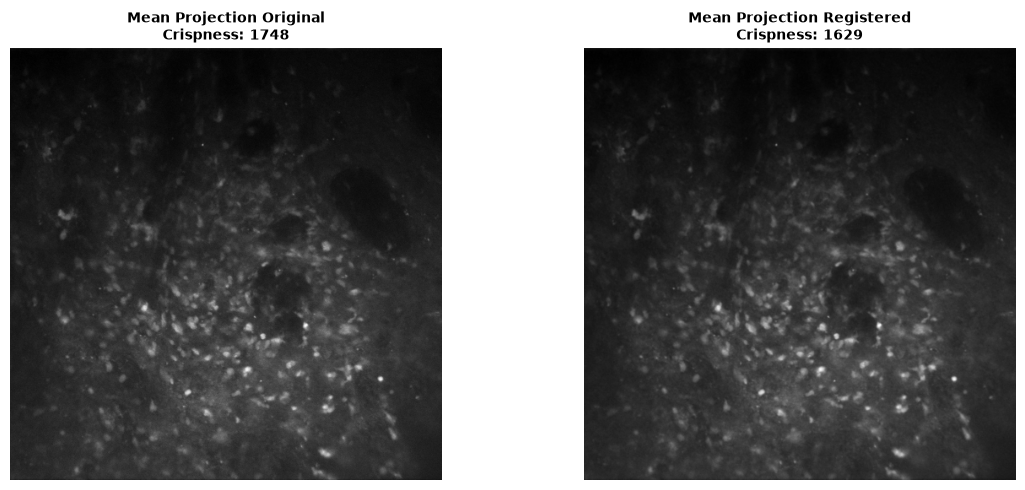

Extracting frame-by-frame intensity profiles...


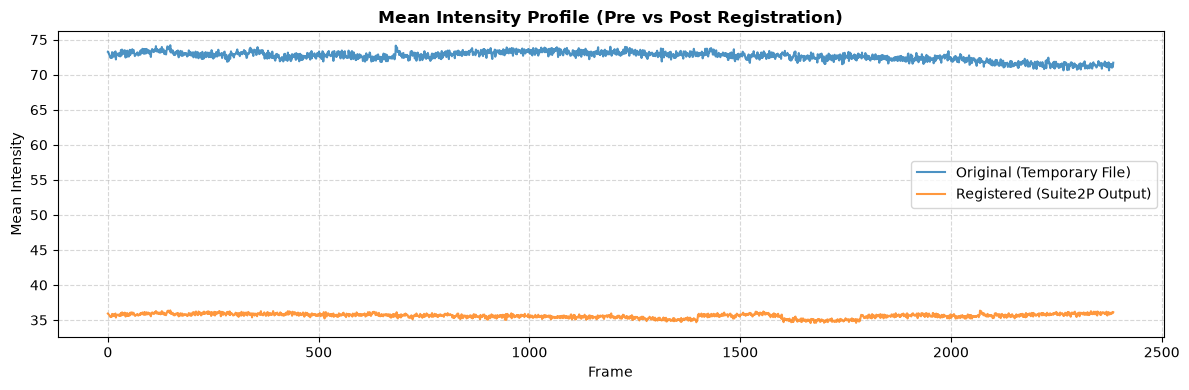

Processing vector offsets (shifts)...


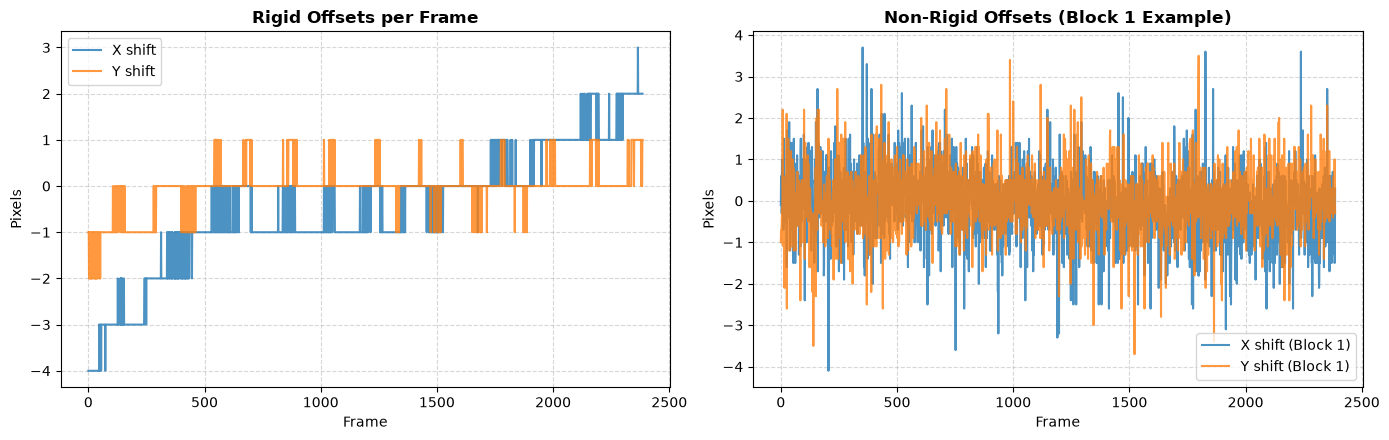

In [23]:
# 7:  MOTION CORRECTION QC
# 7: MOTION CORRECTION QUALITY CONTROL (QC)
%matplotlib inline
from motionQC import run_pipeline_qc

# QC about preprocessing
run_pipeline_qc(paths)